In [14]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [15]:
import torch, glob
import matplotlib.pyplot as plt
import numpy as np
from wassa_plots import plot_hp_tuning, plot_SM, plot_results, plot_similarity_matrix
from wassa_utils import get_best_results, compute_factors_distributions, smoothing
from wassa_training import get_training_parameters, learn_motifs, unsupervised_learning
from wassa_metrics import get_similarity
from wassa import WassA
from dataset_generation import kfold_dataset, generate_dataset, get_dataset_parameters

## Get statistics from real data

In [16]:
dataset_path = '../../allen_data/'
dataset_name = 'bin_tensor_session_00_NM1_trunc'
data = torch.load(dataset_path+dataset_name+'.pt', weights_only = True)

In [17]:
avg_fr = torch.mean(data.to(torch.float),axis=(0,2))*1e3
n_samples, n_neurons, n_timesteps =  data.shape
print(n_samples, n_neurons, n_timesteps)

10 158 5000


In [18]:
avg_fr[avg_fr==0] = .1

## Generate synthetic data

In [19]:
device = 'cuda:1'

In [42]:
dataset_parameters = {
    'seed' : 92,
    
    'N_pre' : n_neurons, # number of neurons
    'N_timesteps' : n_timesteps, # number of timesteps for the raster plot (in ms)
    'N_samples' : n_samples, # total number of samples in the dataset
    'N_SMs' : 4, # number of structured spiking motifs
    'N_delays' : 250, # number of timesteps in spiking motifs, must be a odd number for convolutions
    'overlapping_sms' : False, # possibility to have overlapping sequences

    'temporal_jitter' : 1, # temporal jitter for the spike generation in motifs
    'dropout_proba' : 0, # probabilistic participations of the different neurons to the spiking motif
    'additive_noise' : .1, # percentage of background noise/spontaneous activity
    'warping_coef' : 1, # coefficient for time warping
}
dataset_parameters.update({'N_involved':dataset_parameters['N_pre']*torch.ones(dataset_parameters['N_SMs'])}) # number of neurons involved in the spiking motif
dataset_parameters.update({'freq_sms' : .5*torch.ones(dataset_parameters['N_SMs'],device=device)}) # frequency of apparition of the different spiking motifs (in Hz)
dataset_parameters.update({'frs' : avg_fr.to(device)})
dataset_parameters.update({'coefficient_variation' : 1*torch.ones(dataset_parameters['N_pre'],device=device)}) # coefficient of variation of the FRs of each neuron (within VS. without a motif)

In [43]:
sm, dataset_input, dataset_output = generate_dataset(dataset_parameters, record_path = '../synthetic_data/', device=device)
dataset_name = get_dataset_parameters(dataset_parameters)

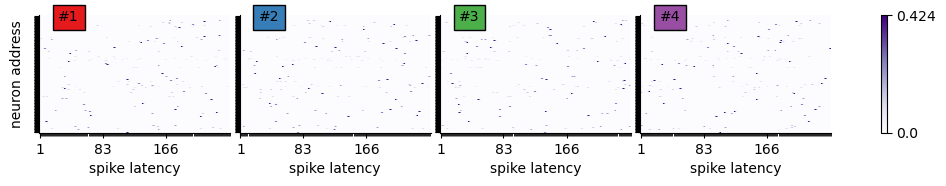

In [44]:
plot_SM(sm.SMs);

In [45]:
training_parameters = {
    'kernel_size' : (dataset_parameters['N_SMs'], dataset_parameters['N_pre'], dataset_parameters['N_delays']),
    'loss_type' : 'mse',
    'activation' : 'conv',
    'topk' : int((dataset_parameters['freq_sms']*dataset_parameters['N_timesteps']*1e-3).mean().item()),
    'kernels_norm' : 2,
    'N_learnsteps' : 400,
    'learning_rate' : 1,
    'penalty_type' : ['cc'],
    'lambda' : [.1],
    'batch_size' : None,
    'do_bias' : [False, True, False],
    'tied_weights' : True,
    'weight_init' : None,
    'normalize_input' : False,
    'reshape_input': False}

In [46]:
# 'penalty value' 'kernels correlation'
metric_names = ['training loss', 'testing loss', 'explained variance', 'kernels similarity']

In [47]:
number_iterations, number_folds = 2, 4
trainsets, testsets, indices = kfold_dataset(dataset_input,k=number_folds)
trainset_output, testset_output, indices = kfold_dataset(dataset_output,k=number_folds)
iteration, k = 2, 0
training_set, testing_set = trainsets[k], testsets[k]
saving_path = '../simulations/'
model = WassA(training_parameters,device=device)
model_name = saving_path+dataset_name+str(iteration)+str(k)+get_training_parameters(training_parameters)
model, training_metrics, metric_names = learn_motifs(model, training_set, testing_set, training_parameters, model_name, metric_names,sm,online_plots=False)

  0%|          | 0/400 [00:00<?, ?it/s]

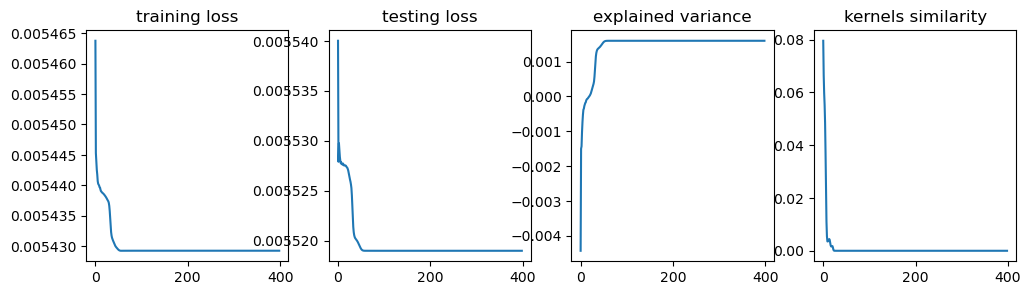

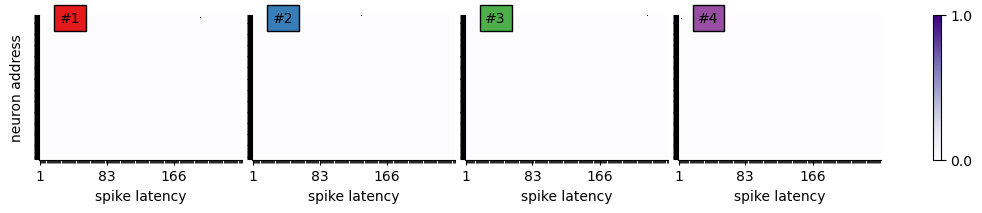

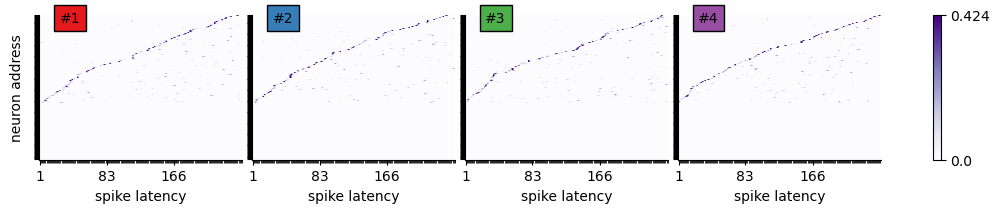

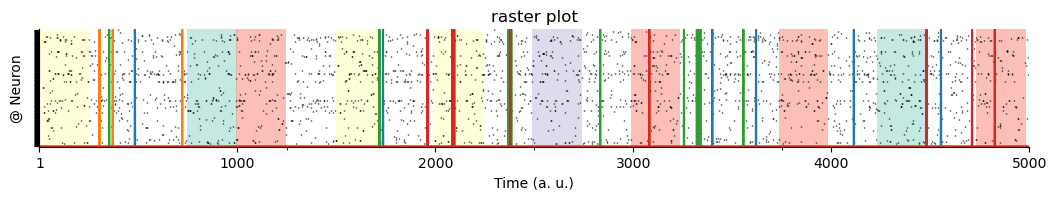

In [48]:
plot_results(training_metrics, metric_names, model, testing_set, order_sms=True, true_occurence=testset_output[k], true_weights=sm.SMs)

In [49]:
similarity_results = get_similarity(sm, model, testing_set,metric_names=synthetic_metrics,verbose=True)

NameError: name 'synthetic_metrics' is not defined

## Check variability for multiple iterations

In [14]:
verb = True
n_iterations = 5
n_folds = 5
results_learning = unsupervised_learning([training_parameters],[sm, dataset_input],metric_names,dataset_name,k_fold=n_folds,n_iter=n_iterations,synthetic_metrics=synthetic_metrics,record_path=saving_path,device=device,verbose=verb)

  0%|          | 0/25 [00:00<?, ?it/s]

  0%|          | 0/2000 [00:00<?, ?it/s]

  0%|          | 0/2000 [00:00<?, ?it/s]

IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)



  0%|          | 0/2000 [00:00<?, ?it/s]

IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)



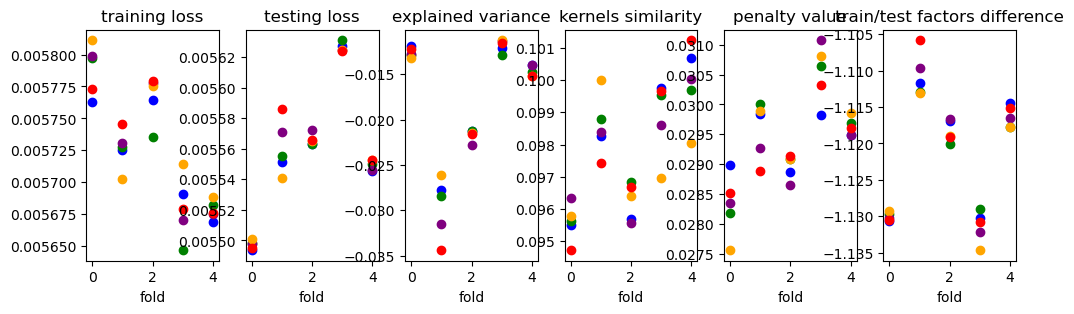

In [15]:
colors = ['blue','green','purple','orange','red']
fig, ax = plt.subplots(1,len(metric_names),figsize=(12,3))
for m in range(len(metric_names)):
    for i in range(results_learning.shape[0]):
        ax[m].scatter(torch.arange(results_learning.shape[1]),results_learning[i,:,m],color=colors[i])
    ax[m].set_title(metric_names[m])
    ax[m].set_xlabel('fold')

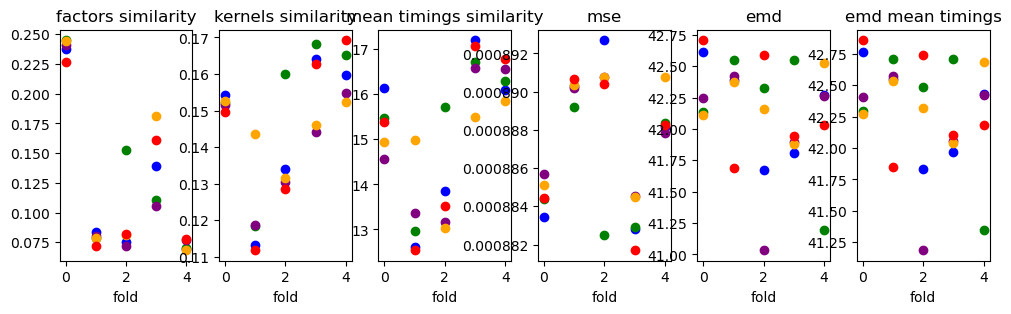

In [16]:
colors = ['blue','green','purple','orange','red']
fig, ax = plt.subplots(1,len(synthetic_metrics),figsize=(12,3))
for m in range(len(synthetic_metrics)):
    for i in range(results_learning.shape[0]):
        ax[m].scatter(torch.arange(results_learning.shape[1]),results_learning[i,:,len(metric_names)+m],color=colors[i])
    ax[m].set_title(synthetic_metrics[m])
    ax[m].set_xlabel('fold')